# UOL Confere: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "uol_confere"
PLAYER = "UOL Confere"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,uol_confere,uol_confere,UOL Confere,20260315T155922Z-f06891f9,20260315T155922Z-f06891f9,20260315T155922Z-f06891f9,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, diagnose_empty_latest_run","20260315T010005Z-1d265f16, 20260314T232736Z-2cced5c3"


SpiderProfile(spider='uol_confere', display_name='UOL Confere', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=('20260315T010005Z-1d265f16', '20260314T232736Z-2cced5c3'), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'diagnose_empty_latest_run'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
28,20260315T155922Z-f06891f9,2026-03-15 15:59:22+00:00,2026-03-15 16:00:10+00:00,906,906,0,0,True,True
24,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,906,0,906,0,True,False
11,20260314T232736Z-2cced5c3,2026-03-14 23:27:36+00:00,2026-03-14 23:28:46+00:00,906,19,887,0,True,True
10,20260304T195736Z-e16e5189,2026-03-04 19:57:36+00:00,2026-03-04 19:58:42+00:00,901,893,8,0,True,True
9,20260304T193821Z-976993d2,2026-03-04 19:38:21+00:00,2026-03-04 19:38:23+00:00,8,4,4,0,True,True
8,20260304T170438Z-540e0c4b,2026-03-04 17:04:38+00:00,2026-03-04 17:04:54+00:00,0,0,0,0,False,False
7,20260304T063146Z-cc82a5b4,2026-03-04 06:31:46+00:00,2026-03-04 06:31:46+00:00,4,4,0,0,True,True
6,20260304T062258Z-cbec5a3c,2026-03-04 06:22:58+00:00,2026-03-04 06:22:58+00:00,0,0,0,0,False,False
5,20260304T062026Z-cad5242f,2026-03-04 06:20:26+00:00,2026-03-04 06:20:26+00:00,0,0,0,0,False,False
4,20260304T061917Z-94f0c15f,2026-03-04 06:19:18+00:00,2026-03-04 06:19:18+00:00,0,0,0,0,False,False


Diagnostic runs configured for this spider:


,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
0,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,906,0,906,0,True,False
1,20260314T232736Z-2cced5c3,2026-03-14 23:27:36+00:00,2026-03-14 23:28:46+00:00,906,19,887,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,UOL Confere,20260315T155922Z-f06891f9,20260315T155922Z-f06891f9,False,906,906,0,2024-09-13 16:17:27+00:00,2026-03-13 20:14:45+00:00,0,27


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,2368e00cf9849edcaf4452f7b4beff1e3fbce0d45cd2e834003f88a8964e2c84,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/governo-nao-pediu-alistamento-por-causa-da-guerra-no-oriente-medio.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/governo-nao-pediu-alistamento-por-causa-da-guerra-no-oriente-medio.htm,Governo Lula não pediu alistamento por causa da guerra no Oriente Médio,2026-03-10T17:15:58.000Z,2026-03-15T15:59:22+00:00,"Atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mulheres também possam se alistar voluntariamente no exército brasileiro","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T155922Z-f06891f9,2026-03-10 17:15:58+00:00,2026-03-15 15:59:22+00:00,118.723333,71,153,138,noticias.uol.com.br,1.0
1,1588b5dcad3404e038b455f556f5cf80888964fa77e43171fe9aaf455fac985a,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/falso-imagem-vorcaro-careca-inss-flavio-bolsonaro.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/falso-imagem-vorcaro-careca-inss-flavio-bolsonaro.htm,"Imagem de Vorcaro, Careca do INSS e Flávio Bolsonaro foi criada por IA",2026-03-10T17:34:26.000Z,2026-03-15T15:59:22+00:00,Foto de inauguração do Banco Master - 2021. Vorcaro - Careca do INSS - Flávio Bolsonaro,"Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T155922Z-f06891f9,2026-03-10 17:34:26+00:00,2026-03-15 15:59:22+00:00,118.415556,70,88,138,noticias.uol.com.br,1.0
2,e3f6c3f4caa0a605ea232d05101361dc524ed44074b1062883fbd2d5ce489480,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/e-falso-que-lula-divulgou-nota-em-apoio-a-ali-khamenei.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/e-falso-que-lula-divulgou-nota-em-apoio-a-ali-khamenei.htm,É falso que Lula divulgou nota em apoio a Ali Khamenei,2026-03-10T18:21:57.000Z,2026-03-15T15:59:22+00:00,"Lula divulga nota em apoio ao ditador e assassino do Irã, Ali Khamenei, líder supremo desde 1989","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T155922Z-f06891f9,2026-03-10 18:21:57+00:00,2026-03-15 15:59:22+00:00,117.623611,54,96,138,noticias.uol.com.br,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_uol_confere:2368e00cf9849edcaf4452f7b4beff1e3fbce0d45cd2e834003f88a8964e2c84,2368e00cf9849edcaf4452f7b4beff1e3fbce0d45cd2e834003f88a8964e2c84,factcheck_scrape_uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/governo-nao-pediu-alistamento-por-causa-da-guerra-no-oriente-medio.htm,2026-03-10T17:15:58+00:00,pt-br,Governo Lula não pediu alistamento por causa da guerra no Oriente Médio,None,None,"Atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mulheres também possam se alistar voluntariamente no exército brasileiro","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.","governo lula não pediu alistamento por causa da guerra no oriente médio atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mul...","governo lula não pediu alistamento por causa da guerra no oriente médio atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mul...",governo lula pediu alistamento causa guerra oriente médio atenção guerra governo brasileiro pede jovens mulheres possam alistar voluntariamente exército bra...,governo lula não pedir alistamento por causa de o guerra em o oriente médio atenção em meio a o guerra governo brasileiro pedir que além de o jovem todo o m...,Falso,false,None,"[{'text': 'governo lula', 'label': 'PER', 'start_char': 0, 'end_char': 12}, {'text': 'brasil', 'label': 'LOC', 'start_char': 276, 'end_char': 282}]",claim_summary,364,2,uol_confere,uol_confere,UOL Confere,20260315T155922Z-f06891f9,20260315T155922Z-f06891f9,False,ClaimReview,[],[],1,2026-03-10 17:15:58+00:00
1,factcheck_scrape_uol_confere:1588b5dcad3404e038b455f556f5cf80888964fa77e43171fe9aaf455fac985a,1588b5dcad3404e038b455f556f5cf80888964fa77e43171fe9aaf455fac985a,factcheck_scrape_uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/falso-imagem-vorcaro-careca-inss-flavio-bolsonaro.htm,2026-03-10T17:34:26+00:00,pt-br,"Imagem de Vorcaro, Careca do INSS e Flávio Bolsonaro foi criada por IA",None,None,Foto de inauguração do Banco Master - 2021. Vorcaro - Careca do INSS - Flávio Bolsonaro,"Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.","imagem de vorcaro, careca do inss e flávio bolsonaro foi criada por ia foto de inauguração do banco master - 2021. vorcaro - careca do inss - flávio bolsona...","imagem de vorcaro, careca do inss e flávio bolsonaro foi criada por ia foto de inauguração do banco master - 2021. vorcaro - careca do inss - flávio bolsona...",imagem vorcaro careca inss flávio bolsonaro criada ia foto inauguração banco master 2021 vorcaro careca inss flávio bolsonaro principais notícias manchetes ...,imagem de vorcaro careca de o inss e flávio bolsonaro ser criar por ir foto de inauguração de o banco master 2021 vorcaro careca de o inss flávio bolsonaro ...,Falso,false,None,"[{'text': 'vorcaro', 'label': 'PER', 'start_char': 10, 'end_char': 17}, {'text': 'flávio bolsonaro', 'label': 'PER', 'start_char': 36, 'end_char': 52}, {'te...",claim_summary,297,5,uol_confere,uol_confere,UOL Confere,20260315T155922Z-f06891f9,20260315T155922Z-f06891f9,False,ClaimReview,[],[],1,2026-03-10 17:34:26+00:00
2,factcheck_scrape_uol_confere:e3f6c3f4caa0a605ea232d05101361dc524ed44074b1062883fbd2d5ce489480,e3f6c3f4caa0a605ea232d05101361dc524ed44074b10628

## Text-length histograms by label

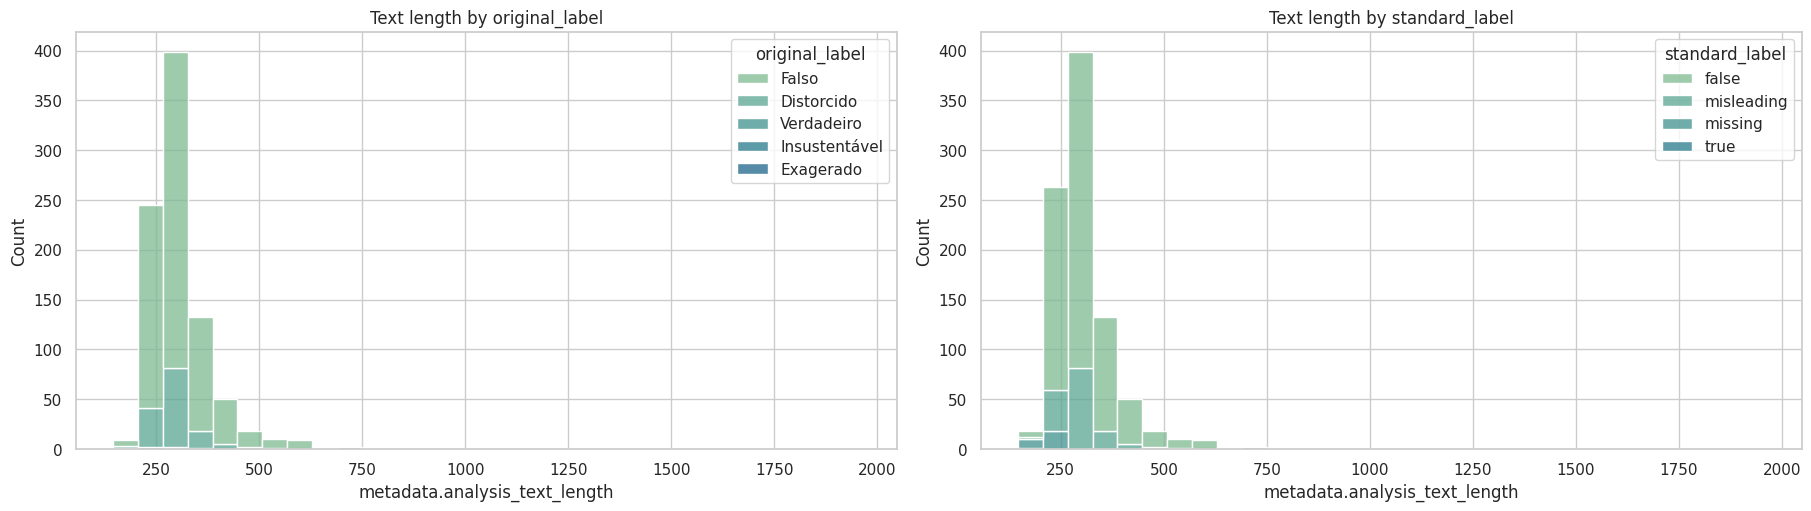

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,None,906


,topic,count


,tag,count


/tmp/ipykernel_2048171/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
0,2024-09-01,43
1,2024-10-01,83
2,2024-11-01,51
3,2024-12-01,50
4,2025-01-01,68
5,2025-02-01,44
6,2025-03-01,38
7,2025-04-01,43
8,2025-05-01,42
9,2025-06-01,50


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,27
4,rating,27
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,2368e00cf9849edcaf4452f7b4beff1e3fbce0d45cd2e834003f88a8964e2c84,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/governo-nao-pediu-alistamento-por-causa-da-guerra-no-oriente-medio.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/governo-nao-pediu-alistamento-por-causa-da-guerra-no-oriente-medio.htm,Governo Lula não pediu alistamento por causa da guerra no Oriente Médio,2026-03-10T17:15:58.000Z,2026-03-15T15:59:22+00:00,"Atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mulheres também possam se alistar voluntariamente no exército brasileiro","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T155922Z-f06891f9,2026-03-10 17:15:58+00:00,2026-03-15 15:59:22+00:00,118.723333,71,153,138,noticias.uol.com.br,1.0,Governo Lula não pediu alistamento por causa da guerra no Oriente Médio,"Atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mulheres também possam se alistar voluntariamente no exército brasileiro","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.","governo lula não pediu alistamento por causa da guerra no oriente médio atenção: em meio à guerra, governo brasileiro pede que além dos jovens, todas as mul...",Falso,false,2026-03-10T17:15:58+00:00
1,1588b5dcad3404e038b455f556f5cf80888964fa77e43171fe9aaf455fac985a,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/falso-imagem-vorcaro-careca-inss-flavio-bolsonaro.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/falso-imagem-vorcaro-careca-inss-flavio-bolsonaro.htm,"Imagem de Vorcaro, Careca do INSS e Flávio Bolsonaro foi criada por IA",2026-03-10T17:34:26.000Z,2026-03-15T15:59:22+00:00,Foto de inauguração do Banco Master - 2021. Vorcaro - Careca do INSS - Flávio Bolsonaro,"Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T155922Z-f06891f9,2026-03-10 17:34:26+00:00,2026-03-15 15:59:22+00:00,118.415556,70,88,138,noticias.uol.com.br,1.0,"Imagem de Vorcaro, Careca do INSS e Flávio Bolsonaro foi criada por IA",Foto de inauguração do Banco Master - 2021. Vorcaro - Careca do INSS - Flávio Bolsonaro,"Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.","imagem de vorcaro, careca do inss e flávio bolsonaro foi criada por ia foto de inauguração do banco master - 2021. vorcaro - careca do inss - flávio bolsona...",Falso,false,2026-03-10T17:34:26+00:00
2,e3f6c3f4caa0a605ea232d05101361dc524ed44074b1062883fbd2d5ce489480,uol_confere,UOL Confere,uol_confere,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/e-falso-que-lula-divulgou-nota-em-apoio-a-ali-khamenei.htm,https://noticias.uol.com.br/confere/ultimas-noticias/2026/03/10/e-falso-que-lula-divulgou-nota-em-apoio-a-ali-khamenei.htm,É falso que Lula divulgou nota em apoio a Ali Khamenei,2026-03-10T18:21:57.000Z,2026-03-15T15:59:22+00:00,"Lula divulga nota em apoio ao ditador e assassino do Irã, Ali Khamenei, líder supremo desde 1989","Veja as principais notícias e manchetes do dia no Brasil e no Mundo. Leia textos e assista a vídeos de Política, Cotidiano, Crimes e mais.",Falso,1,pt-br,BR,[]

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,6133
1,de,4223
2,e,3736
3,em,2699
4,a,1228
5,vídeo,1047
6,ser,998
7,brasil,945
8,mais,842
9,dia,809


,text,label,start_char,end_char
0,governo lula,PER,0,12
0,brasil,LOC,276,282
1,vorcaro,PER,10,17
1,flávio bolsonaro,PER,36,52
1,vorcaro,PER,115,122
1,flávio bolsonaro,PER,142,158
1,brasil,LOC,209,215
2,lula,PER,12,16
2,ali khamenei lula,MISC,42,59
2,irã,LOC,108,111


,label,count
0,LOC,1924
1,PER,1218
2,ORG,282
3,MISC,167


,source_record_id,text_without_stopwords,lemmatized_text
0,2368e00cf9849edcaf4452f7b4beff1e3fbce0d45cd2e834003f88a8964e2c84,governo lula pediu alistamento causa guerra oriente médio atenção guerra governo brasileiro pede jovens mulheres possam alistar voluntariamente exército bra...,governo lula não pedir alistamento por causa de o guerra em o oriente médio atenção em meio a o guerra governo brasileiro pedir que além de o jovem todo o m...
1,1588b5dcad3404e038b455f556f5cf80888964fa77e43171fe9aaf455fac985a,imagem vorcaro careca inss flávio bolsonaro criada ia foto inauguração banco master 2021 vorcaro careca inss flávio bolsonaro principais notícias manchetes ...,imagem de vorcaro careca de o inss e flávio bolsonaro ser criar por ir foto de inauguração de o banco master 2021 vorcaro careca de o inss flávio bolsonaro ...
2,e3f6c3f4caa0a605ea232d05101361dc524ed44074b1062883fbd2d5ce489480,falso lula divulgou nota khamenei lula divulga nota ditador assassino irã khamenei líder supremo 1989 principais notícias manchetes dia brasil mundo leia te...,ser falso que lula divulgar nota em apoio a ali khamenei lula divulgar nota em apoio a o ditador e assassino de o irã ali khamenei líder supremo desde 1989 ...
3,a213e1fbfc91c124892d588f2628da5d1e4d737e44b15c034f911abfd394d932,falso daniel vorcaro surtou entregou esquema lula stf daniel vorcaro surtou prisão entregou nome lula stf boca banqueiro principais notícias manchetes dia b...,ser falso que daniel vorcaro surtar e entregar esquema com lula e stf daniel vorcaro surtar em o prisão e entregar tudo o nome de lula e de o stf em o boca ...
4,5b2aa6a9490e43b55aa69bd636dcfdae2eb2994642f8de6b6d3e148c76986456,lula disse brasil ameaça real invasão estrangeira urgente lula brasil ameaça real invasão principais notícias manchetes dia brasil mundo leia textos assista...,lula não dizer que brasil estar sob ameaça real de invasão estrangeiro urgente lula dizer que brasil estar sob ameaça real de invasão ver o principal notíci...
5,faedf091b780b5fa1854df0c7887271df6d16da807cc4011f4bfb3ac9ce8eb8b,falso fachin sugeriu trocar anulação 8/1 caso master urgente fachin trocar anulação 08/01 prosseguimento ação banco master existe declaração ministro sentid...,ser falso que fachin sugerir trocar anulação de o 8/1 por caso master urgente fachin querer trocar anulação de o 08/01 por o não prosseguimento de o ação de...
6,a1688bb54858e5143bb30bf7f5e62bb31c7fb2c95b4f8aa33693220e7715b21c,netanyahu disse urânio irã veio ocidente urânio brasileiro irã netanyahu primeiro-ministro israel alerta provas urânio veio ocidente faltam testes laboratór...,netanyahu não dizer que urânio de o irã vir de o ocidente urânio brasileiro em o irã netanyahu primeiro-ministro de israel alertar e dizer ter prova que o u...
7,b63ed54f0ae465fa03b780f92a591c7c379b30d67abb8ae953caef8d19277e29,vídeo ahmadinejad anterior guerra prova vivo dado morto israel ex-presidente irã ahmadinejad aparece vivo principais notícias manchetes dia brasil mundo lei...,vídeo de ahmadinejad ser anterior a o guerra e não provar que ele estar vivo dar como matar por israel ex-presidente de o irã ahmadinejad aparecer vivo ver ...
8,43105dd7e716e411ef32a2fdd753e7a208418a9f47a366892dcd6f09f9ab6b6c,irã admitiu atacou escola feminina sul país regime iranino admitiu guarda revolucionária irgc bombardeou engano escola iraniana matando próprias crianças pr...,irã não admitir que atacar escola feminino em o sul de o país o regime iranino admitir que o guarda revolucionária irgc bombardear por engano um escola iran...
9,93575826029cc3cdf5bc42d3d390f3ca680511f6c2ed44cc836f40798530ee69,falso netanyahu irmão ministro morreram ataque irã ataque iraniano atingiu casa benjamin netanyahu matou irmão iddo netanyahu ben gvir ministro segurança na...,ser falso que netanyahu seu irmão e um ministro morrer em ataque de o irã ataque iraniano atingir o casa de benjamin netanyahu e matar seu irmão iddo netany...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T232147Z-uol_confere,906,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232147Z-uol_confere/spiders/uol_confere.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232147Z-uol_confere/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232147Z-uol_confere/manifest.json
